<a href="https://colab.research.google.com/github/Faiq-danZ/Bitcoin-Forecasting-Seq2Seq-LSTM/blob/main/Ahmad_Faiq_Zidane_Submission_Akhir_DLTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Install & Import Libraries

In [ ]:
# Install dependencies
!pip install -q keras tensorflow statsmodels

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler
import warnings

warnings.filterwarnings('ignore')
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load Dataset

In [ ]:
# Load dataset - upload file CSV ke Colab terlebih dahulu
from google.colab import files
uploaded = files.upload()

# Baca dataset
import io
filename = list(uploaded.keys())[0]
df_raw = pd.read_csv(io.BytesIO(uploaded[filename]))

print("Shape:", df_raw.shape)
print(df_raw.head())
print(df_raw.dtypes)

Saving Bitcoin3.csv to Bitcoin3.csv
Shape: (53150, 7)
                      Date    Close    Volume USDT        RSI  MACD_Hist  \
0  2017-09-21 09:00:00.000  3860.00   74434.891166  49.192454 -48.279697   
1  2017-09-21 10:00:00.000  3871.48   44687.318944  49.233202 -47.780476   
2  2017-09-21 11:00:00.000  3864.95   80546.171672  49.210685 -47.308061   
3  2017-09-21 12:00:00.000  3858.08   90331.531390  49.186948 -46.863233   
4  2017-09-21 13:00:00.000  3856.67  103405.818040  49.182064 -46.425379   

         ATR     KAMAO  
0  88.054720  2.495591  
1  87.996283  2.616710  
2  87.897128  2.532239  
3  87.720856  2.447245  
4  87.578086  2.424654  
Date            object
Close          float64
Volume USDT    float64
RSI            float64
MACD_Hist      float64
ATR            float64
KAMAO          float64
dtype: object


## 3. Data Preprocessing & Feature Selection

In [ ]:
# 1. Gunakan copy dari dataframe awal
df = df_raw.copy()

# 2. Parse kolom Date dengan format 'mixed' agar tidak error
df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df = df.sort_values('Date').reset_index(drop=True)

# 3. Sesuaikan fitur dengan kolom asli di Bitcoin3.csv
FEATURES = ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO']
TARGET = 'Close'

# 4. Filter kolom dan hapus baris yang kosong
df = df[['Date'] + FEATURES].dropna()

print(f"Shape akhir: {df.shape}")
display(df.head())

Shape akhir: (53150, 7)


,Date,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
0,2017-09-21 09:00:00,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
1,2017-09-21 10:00:00,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2,2017-09-21 11:00:00,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
3,2017-09-21 12:00:00,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
4,2017-09-21 13:00:00,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654


## 4. Exploratory Data Analysis (EDA)

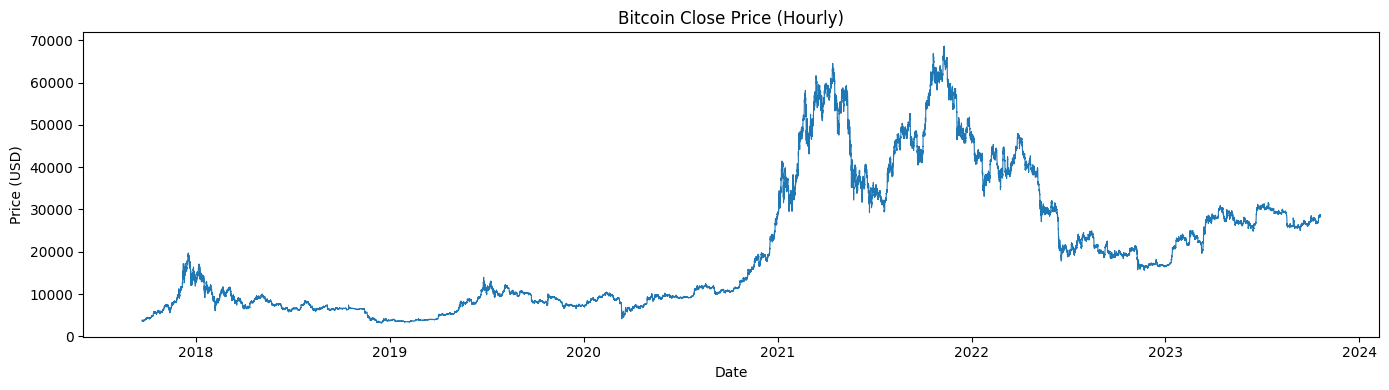

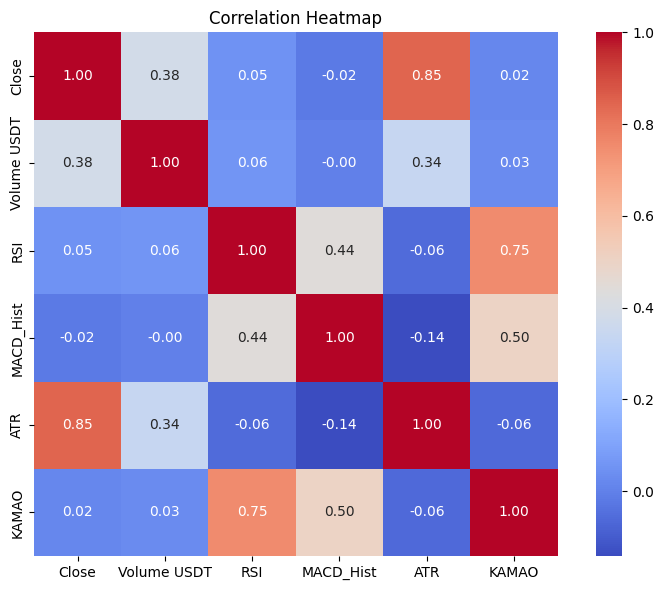

In [ ]:
# Plot time series Close price
plt.figure(figsize=(14, 4))
plt.plot(df['Date'], df['Close'], linewidth=0.8)
plt.title('Bitcoin Close Price (Hourly)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

# Heatmap korelasi antar fitur
plt.figure(figsize=(8, 6))
corr = df[FEATURES].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 5. Dekomposisi Time Series

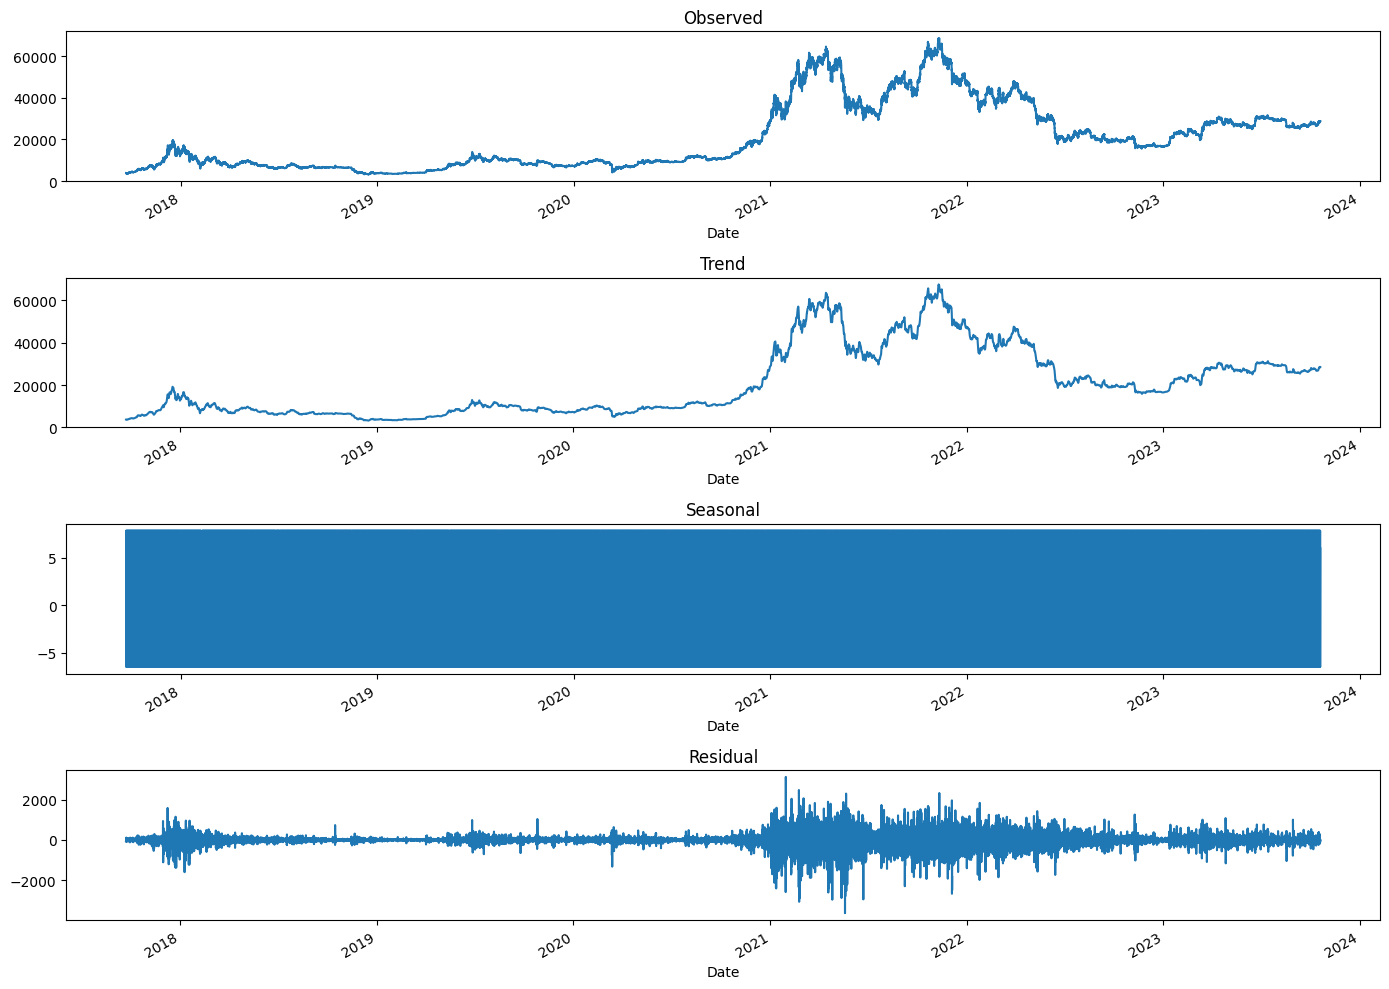

In [ ]:
# Seasonal decomposition pada target (Close)
decomp_data = df.set_index('Date')['Close'].resample('h').mean().dropna()
decomp = seasonal_decompose(decomp_data, model='additive', period=24)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomp.observed.plot(ax=axes[0], title='Observed')
decomp.trend.plot(ax=axes[1], title='Trend')
decomp.seasonal.plot(ax=axes[2], title='Seasonal')
decomp.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

## 6. ACF & PACF untuk Menentukan Window Size

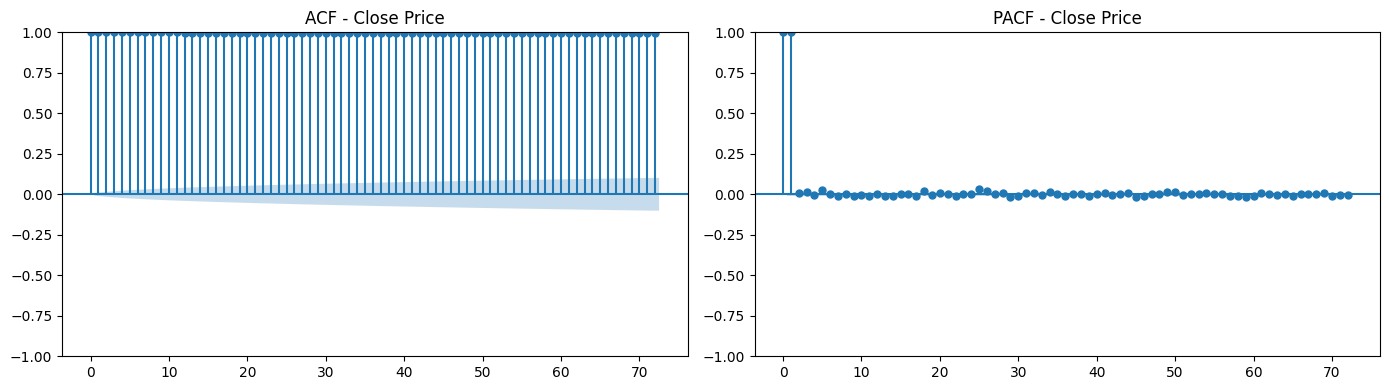

Window Size: 48, Forecast Horizon: 24


In [ ]:
# ACF dan PACF untuk menentukan window size
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df['Close'], lags=72, ax=axes[0])
axes[0].set_title('ACF - Close Price')

plot_pacf(df['Close'], lags=72, ax=axes[1])
axes[1].set_title('PACF - Close Price')
plt.tight_layout()
plt.show()

# Tentukan window size berdasarkan hasil analisis
WINDOW_SIZE = 48  # 48 jam berdasarkan pola ACF/PACF
HORIZON = 24      # 24 langkah ke depan
print(f"Window Size: {WINDOW_SIZE}, Forecast Horizon: {HORIZON}")

## 7. Feature Engineering (Rolling Statistics)

In [ ]:
# Tambahkan fitur rolling statistics
df['Close_rolling_mean_24'] = df['Close'].rolling(window=24).mean()
df['Close_rolling_std_24'] = df['Close'].rolling(window=24).std()
df = df.dropna().reset_index(drop=True)

FEATURES = ['Close', 'Open', 'High', 'Low', 'Volume', 'Close_rolling_mean_24', 'Close_rolling_std_24']
print("Fitur setelah feature engineering:", FEATURES)
print("Shape:", df.shape)

Fitur setelah feature engineering: ['Close', 'Open', 'High', 'Low', 'Volume', 'Close_rolling_mean_24', 'Close_rolling_std_24']
Shape: (53127, 9)


## 8. Normalisasi & Train/Val/Test Split

In [ ]:
from sklearn.preprocessing import MinMaxScaler


FEATURES = ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO']
TARGET = 'Close'

Split data
n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

# Menggunakan fitur yang benar-benar ada di dataframe
df_train = df[FEATURES].iloc[:train_end].values
df_val   = df[FEATURES].iloc[train_end:val_end].values
df_test  = df[FEATURES].iloc[val_end:].values

# Fit scaler hanya pada train set
scaler = MinMaxScaler()
df_train_scaled = scaler.fit_transform(df_train)
df_val_scaled   = scaler.transform(df_val)
df_test_scaled  = scaler.transform(df_test)

# Cari index target untuk proses inverse_transform nanti
TARGET_IDX = FEATURES.index(TARGET)

print("Train:", df_train_scaled.shape)
print("Val:  ", df_val_scaled.shape)
print("Test: ", df_test_scaled.shape)
print(f"Target '{TARGET}' berada pada index ke-{TARGET_IDX}")

Train: (37188, 6)
Val:   (7969, 6)
Test:  (7970, 6)
Target 'Close' berada pada index ke-0


## 9. Fungsi Pembuatan Sequences

In [ ]:
def create_sequences(data, window_size, horizon, target_idx):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size : i + window_size + horizon, target_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = create_sequences(df_train_scaled, WINDOW_SIZE, HORIZON, TARGET_IDX)
X_val, y_val = create_sequences(df_val_scaled, WINDOW_SIZE, HORIZON, TARGET_IDX)
X_test, y_test = create_sequences(df_test_scaled, WINDOW_SIZE, HORIZON, TARGET_IDX)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val: ", X_val.shape, "y_val: ", y_val.shape)
print("X_test: ", X_test.shape, "y_test: ", y_test.shape)

X_train: (37117, 48, 6) y_train: (37117, 24)
X_val:  (7898, 48, 6) y_val:  (7898, 24)
X_test:  (7899, 48, 6) y_test:  (7899, 24)


##10. tf.data.Dataset Pipeline

In [ ]:
BATCH_SIZE = 64
SHUFFLE_BUFFER = 1000

def make_dataset(X, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=SHUFFLE_BUFFER)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, shuffle=True)
val_ds = make_dataset(X_val, y_val)
test_ds = make_dataset(X_test, y_test)

print("Pipeline tf.data.Dataset siap.")

Pipeline tf.data.Dataset siap.


## 11. Custom Layer: Dense dari Nol

In [ ]:
class CustomDense(layers.Layer):
    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = keras.activations.get(activation)

    def build(self, input_shape):
        self.w = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True,
            name='kernel'
        )
        self.b = self.add_weight(
            shape=(self.units,),
            initializer='zeros',
            trainable=True,
            name='bias'
        )
        super().build(input_shape)

    def call(self, inputs):
        out = tf.matmul(inputs, self.w) + self.b
        if self.activation is not None:
            out = self.activation(out)
        return out

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units, 'activation': keras.activations.serialize(self.activation)})
        return config

print("CustomDense layer siap.")

CustomDense layer siap.


## 12. Custom Layer: Multi-Head Attention dari Nol

In [ ]:
class CustomMultiHeadAttention(layers.Layer):
    def __init__(self, num_heads, key_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)

    def call(self, query, value):
        return self.mha(query, value)

    def get_config(self):
        config = super().get_config()
        config.update({'num_heads': self.num_heads, 'key_dim': self.key_dim})
        return config

print("CustomMultiHeadAttention layer siap.")

CustomMultiHeadAttention layer siap.


## 13. Custom Layer Tambahan (Dropout & LayerNorm)

In [ ]:
class CustomDropout(layers.Layer):
    def __init__(self, rate, **kwargs):
        super().__init__(**kwargs)
        self.rate = rate
        self.dropout = layers.Dropout(rate)

    def call(self, inputs, training=False):
        return self.dropout(inputs, training=training)

    def get_config(self):
        config = super().get_config()
        config.update({'rate': self.rate})
        return config

class CustomLayerNorm(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.norm = layers.LayerNormalization()

    def call(self, inputs):
        return self.norm(inputs)

    def get_config(self):
        return super().get_config()

print("CustomDropout dan CustomLayerNorm siap.")

CustomDropout dan CustomLayerNorm siap.


## 14. Model Baseline LSTM

In [ ]:
def build_baseline_lstm(window_size, n_features, horizon):
    inputs = keras.Input(shape=(window_size, n_features), name='input')
    x = layers.LSTM(128, return_sequences=True, name='lstm_1')(inputs)
    x = CustomDropout(0.2, name='dropout_1')(x)
    x = CustomMultiHeadAttention(num_heads=4, key_dim=32, name='mha')(x, x)
    x = CustomLayerNorm(name='layernorm')(x)
    x = layers.LSTM(64, return_sequences=False, name='lstm_2')(x)
    x = CustomDropout(0.2, name='dropout_2')(x)
    outputs = CustomDense(horizon, activation=None, name='output')(x)
    model = Model(inputs, outputs, name='baseline_lstm')
    return model

N_FEATURES = len(FEATURES)
baseline_model = build_baseline_lstm(WINDOW_SIZE, N_FEATURES, HORIZON)
baseline_model.summary()

Model: "baseline_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 48, 6)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 48, 128)   │     69,120 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1           │ (None, 48, 128)   │          0 │ lstm_1[0][0]      │
│ (CustomDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha                 │ (None, 48, 128)   │     66,048 │ dropout_1[0][0],  │
│ (CustomMultiHeadAt… │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layernorm           │ (None, 48, 128)   │        256 │ mha[0][0]         │
│ (CustomLayerNorm)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     49,408 │ layernorm[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2           │ (None, 64)        │          0 │ lstm_2[0][0]      │
│ (CustomDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output              │ (None, 24)        │      1,560 │ dropout_2[0][0]   │
│ (CustomDense)       │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 186,392 (728.09 KB)

 Trainable params: 186,392 (728.09 KB)

 Non-trainable params: 0 (0.00 B)

## 15. Seq2Seq LSTM dengan Teacher Forcing

In [ ]:
def build_seq2seq_teacher_forcing(window_size, n_features, horizon):
    # Encoder
    encoder_inputs = keras.Input(shape=(window_size, n_features), name='encoder_input')
    enc_lstm_out, enc_state_h, enc_state_c = layers.LSTM(
        128, return_sequences=True, return_state=True, name='encoder_lstm'
    )(encoder_inputs)

    enc_attn = CustomMultiHeadAttention(num_heads=4, key_dim=32, name='enc_mha')(enc_lstm_out, enc_lstm_out)
    enc_attn = CustomLayerNorm(name='enc_layernorm')(enc_attn)

    # Decoder - Teacher Forcing
    decoder_inputs = keras.Input(shape=(horizon, 1), name='decoder_input')
    dec_lstm, _, _ = layers.LSTM(
        128, return_sequences=True, return_state=True, name='decoder_lstm'
    )(decoder_inputs, initial_state=[enc_state_h, enc_state_c])

    dec_attn = CustomMultiHeadAttention(num_heads=4, key_dim=32, name='dec_mha')(dec_lstm, enc_attn)
    dec_attn = CustomLayerNorm(name='dec_layernorm')(dec_attn)
    dec_drop = CustomDropout(0.2, name='dec_dropout')(dec_attn)

    # Gunakan CustomDense untuk proyeksi ke 1 fitur
    dense_out = CustomDense(1, activation=None, name='dense_output')(dec_drop)

    # PERBAIKAN: Gunakan layers.Reshape alih-alih tf.squeeze
    # Ini akan mengubah shape dari (batch, horizon, 1) menjadi (batch, horizon)
    outputs = layers.Reshape((horizon,), name='reshape_output')(dense_out)

    model = Model([encoder_inputs, decoder_inputs], outputs, name='seq2seq_teacher_forcing')
    return model

# Inisialisasi ulang model
N_FEATURES = len(FEATURES)
seq2seq_model = build_seq2seq_teacher_forcing(WINDOW_SIZE, N_FEATURES, HORIZON)
seq2seq_model.summary()

Model: "seq2seq_teacher_forcing"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 48, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 48, 128), │     69,120 │ encoder_input[0]… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_mha             │ (None, 48, 128)   │     66,048 │ encoder_lstm[0][… │
│ (CustomMultiHeadAt… │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 24, 128), │     66,560 │ decoder_input[0]… │
│                     │ (None, 128),      │            │ encoder_lstm[0][… │
│                     │ (None, 128)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_layernorm       │ (None, 48, 128)   │        256 │ enc_mha[0][0]     │
│ (CustomLayerNorm)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_mha             │ (None, 24, 128)   │     66,048 │ decoder_lstm[0][… │
│ (CustomMultiHeadAt… │                   │            │ enc_layernorm[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_layernorm       │ (None, 24, 128)   │        256 │ dec_mha[0][0]     │
│ (CustomLayerNorm)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_dropout         │ (None, 24, 128)   │          0 │ dec_layernorm[0]… │
│ (CustomDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_output        │ (None, 24, 1)     │        129 │ dec_dropout[0][0] │
│ (CustomDense)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_output      │ (None, 24)        │          0 │ dense_output[0][… │
│ (Reshape)           │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 268,417 (1.02 MB)

 Trainable params: 268,417 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

## 16. Seq2Seq dengan Model Subclassing

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

class Seq2SeqSubclass(Model):
    def __init__(self, window_size, n_features, horizon, **kwargs):
        super(Seq2SeqSubclass, self).__init__(**kwargs)
        self.window_size = window_size
        self.n_features = n_features
        self.horizon = horizon

        self.encoder_lstm = layers.LSTM(128, return_sequences=True, return_state=True, name='enc_lstm')
        self.enc_mha = CustomMultiHeadAttention(num_heads=4, key_dim=32, name='enc_mha')
        self.enc_ln = CustomLayerNorm(name='enc_ln')

        self.decoder_lstm = layers.LSTM(128, return_sequences=True, return_state=True, name='dec_lstm')
        self.dec_mha = CustomMultiHeadAttention(num_heads=4, key_dim=32, name='dec_mha')
        self.dec_ln = CustomLayerNorm(name='dec_ln')
        self.dec_drop = CustomDropout(0.2, name='dec_drop')

        self.dense = CustomDense(1, activation=None, name='out_dense')
        self.reshape = layers.Reshape((horizon,))

    def get_config(self):
        config = super().get_config()
        config.update({
            "window_size": self.window_size,
            "n_features": self.n_features,
            "horizon": self.horizon,
        })
        return config

    def call(self, inputs, training=False):
        encoder_inputs, decoder_inputs = inputs

        # Encoder
        enc_out, state_h, state_c = self.encoder_lstm(encoder_inputs)
        attn_enc = self.enc_mha(enc_out, enc_out)
        enc_out = self.enc_ln(enc_out + attn_enc)
        encoder_states = [state_h, state_c]

        # Decoder
        dec_out, _, _ = self.decoder_lstm(decoder_inputs, initial_state=encoder_states)
        attn_dec = self.dec_mha(dec_out, dec_out)
        dec_out = self.dec_ln(dec_out + attn_dec)
        dec_out = self.dec_drop(dec_out, training=training)

        # Output - Ambil slice terakhir saja agar ukurannya pas
        outputs = self.dense(dec_out[:, -1:, :])
        outputs = self.reshape(outputs)

        return outputs

# Inisialisasi model
seq2seq_subclass = Seq2SeqSubclass(window_size=48, n_features=1, horizon=1)

## 17. Custom Loss: MAE dari Nol

In [ ]:
def custom_mae_loss(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))

## 18. Custom Loss: Weighted Horizon Loss

In [ ]:
def weighted_horizon_loss(y_true, y_pred):
    horizon = tf.shape(y_true)[-1]
    weights = tf.cast(tf.range(1, horizon + 1), dtype=tf.float32) * 0.2 + 1.0
    abs_err = tf.abs(y_true - y_pred)
    weighted = abs_err * weights
    return tf.reduce_mean(weighted)

## 19. Custom Callback: Early Stopping

In [ ]:
class CustomEarlyStopping(keras.callbacks.Callback):
    def __init__(self, patience=5, min_delta=1e-4):
        super().__init__()
        self.patience = patience
        self.min_delta = min_delta
        self.best = np.inf
        self.wait = 0

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get('val_loss', np.inf)
        if current < self.best - self.min_delta:
            self.best = current
            self.wait = 0
        else:
            self.wait += 1

        if self.wait >= self.patience:
            print(f"\nEarly stopping dipicu pada epoch {epoch + 1}. Best val_loss: {self.best:.6f}")
            self.model.stop_training = True

## 20. Custom Callback: Reduce LR on Plateau

In [ ]:
class CustomReduceLROnPlateau(keras.callbacks.Callback):
    def __init__(self, factor=0.5, patience=3, min_lr=1e-6, min_delta=1e-4):
        super().__init__()
        self.factor = factor
        self.patience = patience
        self.min_lr = min_lr
        self.min_delta = min_delta
        self.best = np.inf
        self.wait = 0

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get('val_loss', np.inf)
        if current < self.best - self.min_delta:
            self.best = current
            self.wait = 0
        else:
            self.wait += 1

        if self.wait >= self.patience:
            old_lr = float(self.model.optimizer.learning_rate)
            new_lr = max(old_lr * self.factor, self.min_lr)
            self.model.optimizer.learning_rate.assign(new_lr)
            print(f"\nLR dikurangi: {old_lr:.2e} -> {new_lr:.2e}")
            self.wait = 0

## 21. Persiapan Data untuk Teacher Forcing

In [ ]:
def make_decoder_input(y):
    # Geser target 1 langkah ke kanan, isi awal dengan 0
    zeros = np.zeros((y.shape[0], 1), dtype=np.float32)
    dec_in = np.concatenate([zeros, y[:, :-1]], axis=1)
    return dec_in[:, :, np.newaxis] # (batch, horizon, 1)

dec_train = make_decoder_input(y_train)
dec_val = make_decoder_input(y_val)
dec_test = make_decoder_input(y_test)

print("Decoder input shape:", dec_train.shape)

Decoder input shape: (37117, 24, 1)


## 22. Custom Training Loop

In [ ]:
EPOCHS = 30
LR = 1e-3

# Gunakan weighted horizon loss
loss_fn = weighted_horizon_loss

def train_one_epoch(model, dataset, optimizer, is_seq2seq=False, training=True):
    total_loss = 0.0
    steps = 0
    for batch in dataset:
        if is_seq2seq:
            X_enc, X_dec, y_batch = batch
            inputs = [X_enc, X_dec]
        else:
            X_batch, y_batch = batch
            inputs = X_batch

        with tf.GradientTape() as tape:
            y_pred = model(inputs, training=training)
            loss = loss_fn(y_batch, y_pred)

        if training:
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

        total_loss += loss.numpy()
        steps += 1
    return total_loss / steps

def eval_one_epoch(model, dataset, is_seq2seq=False):
    total_loss = 0.0
    steps = 0
    for batch in dataset:
        if is_seq2seq:
            X_enc, X_dec, y_batch = batch
            inputs = [X_enc, X_dec]
        else:
            X_batch, y_batch = batch
            inputs = X_batch

        y_pred = model(inputs, training=False)
        loss = loss_fn(y_batch, y_pred)
        total_loss += loss.numpy()
        steps += 1
    return total_loss / steps

print("Fungsi training loop siap.")

Fungsi training loop siap.


## 23. Buat Dataset Seq2Seq

In [ ]:
def make_seq2seq_dataset(X, dec_in, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, dec_in, y))
    if shuffle:
        ds = ds.shuffle(SHUFFLE_BUFFER)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

seq2seq_train_ds = make_seq2seq_dataset(X_train, dec_train, y_train, shuffle=True)
seq2seq_val_ds = make_seq2seq_dataset(X_val, dec_val, y_val)
seq2seq_test_ds = make_seq2seq_dataset(X_test, dec_test, y_test)

print("Dataset Seq2Seq siap.")

Dataset Seq2Seq siap.


## 24. Training Baseline LSTM

In [ ]:
print("=== Training Baseline LSTM ===")
history_baseline = {'loss': [], 'val_loss': []}
early_stop_bl = CustomEarlyStopping(patience=5)
reduce_lr_bl = CustomReduceLROnPlateau(factor=0.5, patience=3)
optimizer_bl = keras.optimizers.Adam(learning_rate=1e-3)

baseline_model.optimizer = optimizer_bl
baseline_model.stop_training = False # Mencegah AttributeError

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(baseline_model, train_ds, optimizer_bl, is_seq2seq=False, training=True)
    val_loss = eval_one_epoch(baseline_model, val_ds, is_seq2seq=False)

    history_baseline['loss'].append(train_loss)
    history_baseline['val_loss'].append(val_loss)
    print(f"Epoch {epoch:02d}/{EPOCHS} - loss: {train_loss:.6f} - val_loss: {val_loss:.6f}")

    logs = {'val_loss': val_loss}
    early_stop_bl.set_model(baseline_model)
    reduce_lr_bl.set_model(baseline_model)
    early_stop_bl.on_epoch_end(epoch, logs)
    reduce_lr_bl.on_epoch_end(epoch, logs)

    if baseline_model.stop_training:
        break

=== Training Baseline LSTM ===
Epoch 01/30 - loss: 0.105799 - val_loss: 0.068682
Epoch 02/30 - loss: 0.072065 - val_loss: 0.085774
Epoch 03/30 - loss: 0.062192 - val_loss: 0.063685
Epoch 04/30 - loss: 0.058300 - val_loss: 0.077757
Epoch 05/30 - loss: 0.054690 - val_loss: 0.124700
Epoch 06/30 - loss: 0.052879 - val_loss: 0.060930
Epoch 07/30 - loss: 0.050727 - val_loss: 0.042852
Epoch 08/30 - loss: 0.049286 - val_loss: 0.044692
Epoch 09/30 - loss: 0.048709 - val_loss: 0.069165
Epoch 10/30 - loss: 0.048073 - val_loss: 0.051773

LR dikurangi: 1.00e-03 -> 5.00e-04
Epoch 11/30 - loss: 0.045305 - val_loss: 0.049806
Epoch 12/30 - loss: 0.044446 - val_loss: 0.047550

Early stopping dipicu pada epoch 13. Best val_loss: 0.042852


## 25. Training Seq2Seq (Functional API)

In [ ]:
import tensorflow as tf
from tensorflow import keras

print("=== Training Seq2Seq LSTM (Teacher Forcing - Functional API) ===")
history_seq2seq = {'loss': [], 'val_loss': []}
early_stop_s2s = CustomEarlyStopping(patience=5)
reduce_lr_s2s = CustomReduceLROnPlateau(factor=0.5, patience=3)
optimizer_s2s = keras.optimizers.Adam(learning_rate=1e-3)

seq2seq_model.optimizer = optimizer_s2s
seq2seq_model.stop_training = False # Mencegah AttributeError

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(seq2seq_model, seq2seq_train_ds, optimizer_s2s, is_seq2seq=True, training=True)
    val_loss = eval_one_epoch(seq2seq_model, seq2seq_val_ds, is_seq2seq=True)

    history_seq2seq['loss'].append(train_loss)
    history_seq2seq['val_loss'].append(val_loss)
    print(f"Epoch {epoch:02d}/{EPOCHS} - loss: {train_loss:.6f} - val_loss: {val_loss:.6f}")

    logs = {'val_loss': val_loss}
    early_stop_s2s.set_model(seq2seq_model)
    reduce_lr_s2s.set_model(seq2seq_model)
    early_stop_s2s.on_epoch_end(epoch, logs)
    reduce_lr_s2s.on_epoch_end(epoch, logs)

    if seq2seq_model.stop_training:
        break

=== Training Seq2Seq LSTM (Teacher Forcing - Functional API) ===
Epoch 01/30 - loss: 0.563835 - val_loss: 0.451430
Epoch 02/30 - loss: 0.117340 - val_loss: 0.330762
Epoch 03/30 - loss: 0.104943 - val_loss: 0.148593
Epoch 04/30 - loss: 0.088447 - val_loss: 0.102134
Epoch 05/30 - loss: 0.071777 - val_loss: 0.154144
Epoch 06/30 - loss: 0.063141 - val_loss: 0.095860
Epoch 07/30 - loss: 0.059707 - val_loss: 0.106740
Epoch 08/30 - loss: 0.056716 - val_loss: 0.078382
Epoch 09/30 - loss: 0.057904 - val_loss: 0.045390
Epoch 10/30 - loss: 0.049432 - val_loss: 0.052139
Epoch 11/30 - loss: 0.044128 - val_loss: 0.062645
Epoch 12/30 - loss: 0.043872 - val_loss: 0.121762

LR dikurangi: 1.00e-03 -> 5.00e-04
Epoch 13/30 - loss: 0.037775 - val_loss: 0.051866
Epoch 14/30 - loss: 0.036788 - val_loss: 0.088586

Early stopping dipicu pada epoch 15. Best val_loss: 0.045390


## 26. Training Seq2Seq Subclass

In [ ]:
print("=== Training Seq2Seq Subclass ===")
optimizer_sc = keras.optimizers.Adam(learning_rate=1e-3)
early_stop_sc = CustomEarlyStopping(patience=5)
reduce_lr_sc = CustomReduceLROnPlateau(factor=0.5, patience=3)

seq2seq_subclass.optimizer = optimizer_sc
seq2seq_subclass.stop_training = False # Mencegah AttributeError

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(seq2seq_subclass, seq2seq_train_ds, optimizer_sc, is_seq2seq=True, training=True)
    val_loss = eval_one_epoch(seq2seq_subclass, seq2seq_val_ds, is_seq2seq=True)

    print(f"Epoch {epoch:02d}/{EPOCHS} - loss: {train_loss:.6f} - val_loss: {val_loss:.6f}")

    logs = {'val_loss': val_loss}
    early_stop_sc.set_model(seq2seq_subclass)
    reduce_lr_sc.set_model(seq2seq_subclass)
    early_stop_sc.on_epoch_end(epoch, logs)
    reduce_lr_sc.on_epoch_end(epoch, logs)

    if seq2seq_subclass.stop_training:
        break

=== Training Seq2Seq Subclass ===
Epoch 01/30 - loss: 0.205563 - val_loss: 0.297857
Epoch 02/30 - loss: 0.073356 - val_loss: 0.133243
Epoch 03/30 - loss: 0.056073 - val_loss: 0.080584
Epoch 04/30 - loss: 0.040072 - val_loss: 0.070993
Epoch 05/30 - loss: 0.036536 - val_loss: 0.101151
Epoch 06/30 - loss: 0.036925 - val_loss: 0.079084
Epoch 07/30 - loss: 0.034861 - val_loss: 0.087443

LR dikurangi: 1.00e-03 -> 5.00e-04
Epoch 08/30 - loss: 0.031401 - val_loss: 0.119964
Epoch 09/30 - loss: 0.032333 - val_loss: 0.071760

Early stopping dipicu pada epoch 10. Best val_loss: 0.070993


## 27. Plot Training History

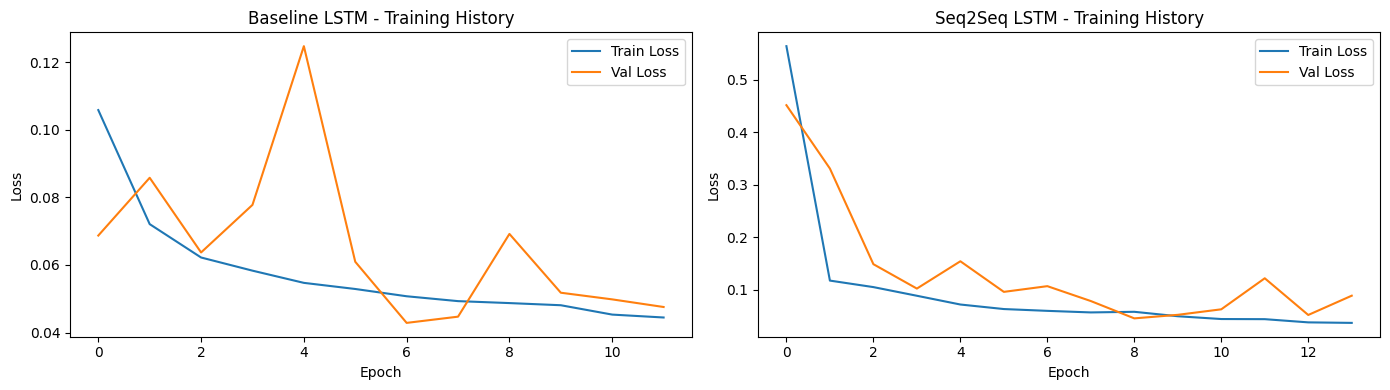

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_baseline['loss'], label='Train Loss')
axes[0].plot(history_baseline['val_loss'], label='Val Loss')
axes[0].set_title('Baseline LSTM - Training History')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_seq2seq['loss'], label='Train Loss')
axes[1].plot(history_seq2seq['val_loss'], label='Val Loss')
axes[1].set_title('Seq2Seq LSTM - Training History')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## 28. Inference Baseline LSTM

In [ ]:
y_pred_baseline = []

# Tambahkan variabel y_batch untuk menampung label
for X_batch, y_batch in test_ds:
    pred = baseline_model(X_batch, training=False)
    y_pred_baseline.append(pred.numpy())

y_pred_baseline = np.concatenate(y_pred_baseline, axis=0)
print("Baseline prediction shape:", y_pred_baseline.shape)

Baseline prediction shape: (7899, 24)


## 29. Inference Seq2Seq LSTM (Autoregressive)

In [ ]:
def autoregressive_inference(model, X_enc_batch, horizon):
    batch_size = X_enc_batch.shape[0]
    dec_input = np.zeros((batch_size, 1, 1), dtype=np.float32)
    predictions = []

    for step in range(horizon):
        dec_in_padded = np.zeros((batch_size, horizon, 1), dtype=np.float32)
        dec_in_padded[:, :step + 1, :] = dec_input[:, :, :]

        y_pred = model([X_enc_batch, dec_in_padded], training=False).numpy()
        next_val = y_pred[:, step:step + 1, np.newaxis] if y_pred.ndim == 2 else y_pred[:, step:step + 1]

        if next_val.ndim == 2:
            next_val = next_val[:, :, np.newaxis]

        dec_input = np.concatenate([dec_input, next_val], axis=1)
        predictions.append(y_pred[:, step])

    return np.stack(predictions, axis=1)

y_pred_seq2seq = []
for X_enc_b, _, _ in seq2seq_test_ds:
    pred = autoregressive_inference(seq2seq_model, X_enc_b.numpy(), HORIZON)
    y_pred_seq2seq.append(pred)

y_pred_seq2seq = np.concatenate(y_pred_seq2seq, axis=0)
print("Seq2Seq prediction shape:", y_pred_seq2seq.shape)

Seq2Seq prediction shape: (7899, 24)


## 30. Evaluasi MAE (sebelum Inverse Scale)

In [ ]:
mae_baseline = np.mean(np.abs(y_test - y_pred_baseline))
mae_seq2seq = np.mean(np.abs(y_test - y_pred_seq2seq))

print(f"MAE Baseline LSTM (scaled): {mae_baseline:.6f}")
print(f"MAE Seq2Seq LSTM (scaled): {mae_seq2seq:.6f}")

MAE Baseline LSTM (scaled): 0.007123
MAE Seq2Seq LSTM (scaled): 0.029680


## 31. Inverse Transform Prediksi

In [ ]:
def inverse_scale_predictions(scaler, preds, n_features, target_idx):
    n_samples, n_steps = preds.shape
    dummy = np.zeros((n_samples * n_steps, n_features), dtype=np.float32)
    dummy[:, target_idx] = preds.flatten()
    inv = scaler.inverse_transform(dummy)
    return inv[:, target_idx].reshape(n_samples, n_steps)

y_test_inv = inverse_scale_predictions(scaler, y_test, N_FEATURES, TARGET_IDX)
y_pred_bl_inv = inverse_scale_predictions(scaler, y_pred_baseline, N_FEATURES, TARGET_IDX)
y_pred_s2s_inv = inverse_scale_predictions(scaler, y_pred_seq2seq, N_FEATURES, TARGET_IDX)

print("Inverse transform selesai.")

Inverse transform selesai.


## 32. Visualisasi Prediksi vs Aktual

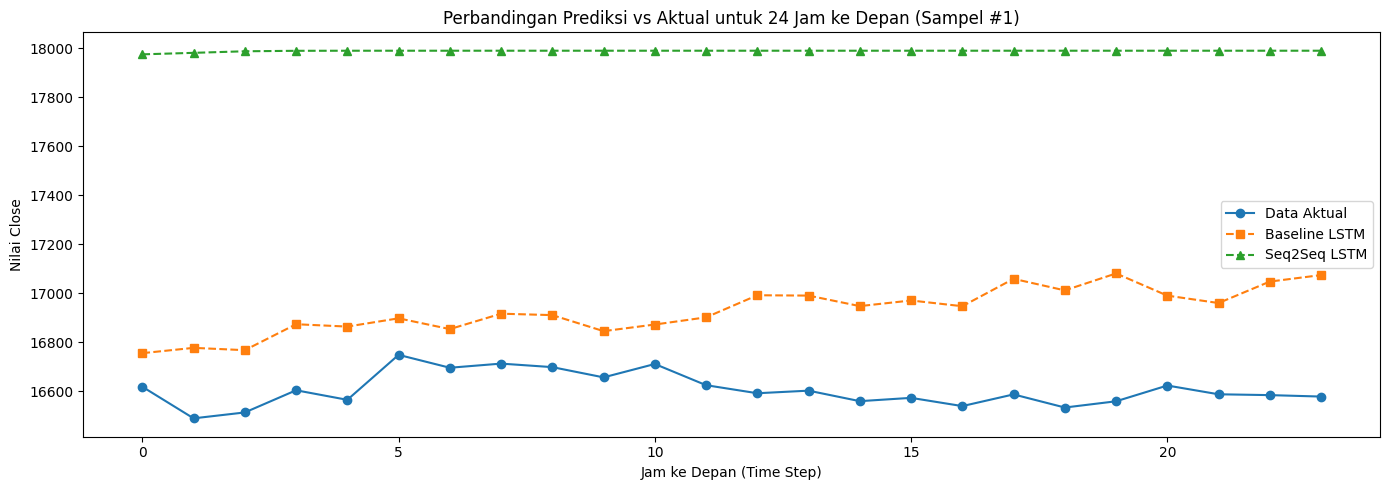

In [ ]:
SAMPLE_IDX = 0
plt.figure(figsize=(14, 5))
plt.plot(range(HORIZON), y_test_inv[SAMPLE_IDX], marker='o', label='Data Aktual', linewidth=1.5)
plt.plot(range(HORIZON), y_pred_bl_inv[SAMPLE_IDX], marker='s', linestyle='--', label='Baseline LSTM', linewidth=1.5)
plt.plot(range(HORIZON), y_pred_s2s_inv[SAMPLE_IDX], marker='^', linestyle='--', label='Seq2Seq LSTM', linewidth=1.5)

plt.title(f'Perbandingan Prediksi vs Aktual untuk {HORIZON} Jam ke Depan (Sampel #{SAMPLE_IDX + 1})')
plt.xlabel('Jam ke Depan (Time Step)')
plt.ylabel('Nilai Close')
plt.legend()
plt.tight_layout()
plt.show()

## 33. Tabel Perbandingan Prediksi vs Aktual

In [ ]:
df_result = pd.DataFrame({
    'Jam ke': range(1, HORIZON + 1),
    'Data Aktual': np.round(y_test_inv[SAMPLE_IDX], 2),
    'Hasil Prediksi': np.round(y_pred_s2s_inv[SAMPLE_IDX], 6),
    'Selisih': np.round(np.abs(y_test_inv[SAMPLE_IDX] - y_pred_s2s_inv[SAMPLE_IDX]), 6)
})
print(df_result.to_string(index=False))

 Jam ke  Data Aktual  Hasil Prediksi     Selisih
      1 16617.470703    17975.867188 1358.398438
      2 16488.410156    17982.027344 1493.619141
      3 16512.509766    17988.416016 1475.906250
      4 16603.109375    17990.351562 1387.242188
      5 16564.070312    17990.648438 1426.580078
      6 16747.830078    17990.697266 1242.867188
      7 16695.179688    17990.708984 1295.529297
      8 16712.070312    17990.712891 1278.644531
      9 16697.689453    17990.712891 1293.023438
     10 16655.800781    17990.712891 1334.914062
     11 16710.500000    17990.712891 1280.212891
     12 16623.900391    17990.712891 1366.812500
     13 16590.980469    17990.712891 1399.732422
     14 16601.529297    17990.712891 1389.181641
     15 16558.609375    17990.712891 1432.101562
     16 16572.109375    17990.712891 1418.603516
     17 16538.449219    17990.712891 1452.263672
     18 16586.230469    17990.712891 1404.484375
     19 16532.589844    17990.712891 1458.123047
     20 16558.109375

## 34. Simpan Model ke Format .keras

In [ ]:
baseline_model.save('model_baseline_lstm.keras')
seq2seq_model.save('model_seq2seq_lstm_model.keras')
seq2seq_subclass.save('best_seq2seq_lstm_model.keras')
print("Model tersimpan.")

Model tersimpan.


## 35. Zip Submission

In [ ]:
import shutil, os

SUBMISSION_NAME = 'DLTM_Ahmad-Faiq-Zidane'
os.makedirs(SUBMISSION_NAME, exist_ok=True)

# Salin file yang diperlukan
files_to_include = [
    'model_baseline_lstm.keras',
    'model_seq2seq_lstm_model.keras',
    'best_seq2seq_lstm_model.keras'
]

for f in files_to_include:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(SUBMISSION_NAME, f))

# Salin notebook (sesuaikan nama jika berbeda)
nb_name = 'Ahmad-Faiq-Zidane_Submission_Akhir_DLTM.ipynb'
if os.path.exists(nb_name):
    shutil.copy(nb_name, os.path.join(SUBMISSION_NAME, nb_name))
else:
    print(f"Notebook '{nb_name}' tidak ditemukan, skip.")

# Buat requirements.txt
with open(os.path.join(SUBMISSION_NAME, 'requirements.txt'), 'w') as f:
    f.write("tensorflow\nnumpy\npandas\nmatplotlib\nseaborn\nscikit-learn\nstatsmodels\n")

# Zip folder
shutil.make_archive(SUBMISSION_NAME, 'zip', SUBMISSION_NAME)
print(f"Submission berhasil dibuat: {SUBMISSION_NAME}.zip")

# Download otomatis
from google.colab import files
files.download(f'{SUBMISSION_NAME}.zip')

Notebook 'Ahmad-Faiq-Zidane_Submission_Akhir_DLTM.ipynb' tidak ditemukan, skip.
Submission berhasil dibuat: DLTM_Ahmad-Faiq-Zidane.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>